In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.interpolate import UnivariateSpline
from braid_analysis import flymath
import pynumdiff

from align_course_direction_analysis import unifying_algo_analysis as uaa

import figurefirst as fifi

In [2]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

### Parameters

In [3]:
fname = 'crab_12710.csv'
df_raw_vx = pd.read_csv('../../../../../Data/Animal_Trajectory_Data/crabs/crab_12710_vx.csv')
df_raw_vy = pd.read_csv('../../../../../Data/Animal_Trajectory_Data/crabs/crab_12710_vy.csv')
flow_direction = np.pi

flow_condition = 'laminar'
flow_speed = 0.05
body_length = 0.1
locomotion = 'walking'
medium = 'water'
group = 'aquatic'

interp_dt = 0.01

### Get time stamps and speed -- this is custom per data type

In [4]:
# drop backwards times

ix_vx_drop = np.where(np.diff(df_raw_vx.time.values)<0)[0]
df_raw_vx = df_raw_vx.drop(ix_vx_drop)
df_raw_vx.xvel /= 100

ix_vy_drop = np.where(np.diff(df_raw_vy.time.values)<0)[0]
df_raw_vy = df_raw_vy.drop(ix_vy_drop) 
df_raw_vy.yvel /= 100

In [5]:
interp_timestamps_sec = np.arange(df_raw_vx.time.min(), df_raw_vx.time.max(), 0.1)

In [6]:
spline_x = UnivariateSpline(df_raw_vx.time, df_raw_vx.xvel, s=1e-3, k=3)  # s=smoothing amount
interp_vx = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_raw_vy.time, df_raw_vy.yvel, s=1e-3, k=3)  # s=smoothing amount
interp_vy = spline_y(interp_timestamps_sec)

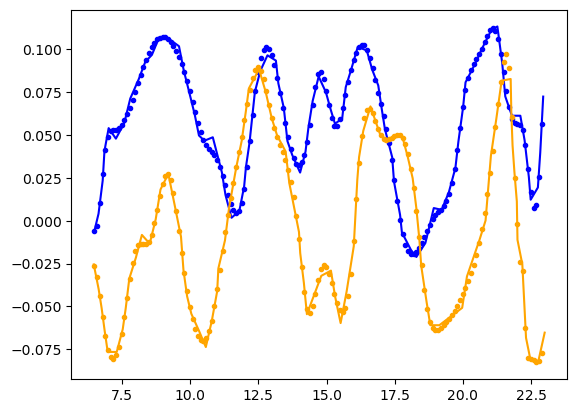

In [7]:
plt.plot(df_raw_vx.time.values, df_raw_vx.xvel.values, color='blue')
plt.plot(interp_timestamps_sec, interp_vx, '.', color='blue')


plt.plot(df_raw_vy.time.values, df_raw_vy.yvel.values, color='orange')
plt.plot(interp_timestamps_sec, interp_vy, '.', color='orange')

In [8]:
dt = np.median(np.diff(interp_timestamps_sec))
x = np.cumsum(interp_vx*dt)
y = np.cumsum(interp_vy*dt)

In [9]:
df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': x,
                                     'y': y,
                                     'xvel': interp_vx,
                                     'yvel': interp_vy})

### Parameters

In [10]:
df_calibrated_interp.shape

(165, 5)

In [11]:
tix_start = 20
tix_end = 164

8.489420720199993


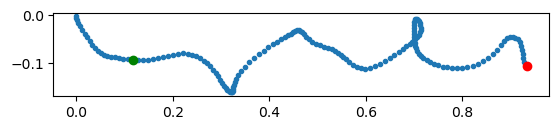

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

#ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

# when does search start
ax.plot(df_calibrated_interp.x.values[tix_start], df_calibrated_interp.y.values[tix_start], 'o', color='green')

# when does search end?
ax.plot(df_calibrated_interp.x.values[tix_end], df_calibrated_interp.y.values[tix_end], 'o', color='red')

print(df_calibrated_interp.timestamps_sec.values[tix_start])

ax.set_aspect('equal')

In [13]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [14]:
df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix_start]
df_calibrated_interp['obj_id_unique_event'] = fname.split('.')[0]
df_calibrated_interp['obj_id_unique'] = fname.split('.')[0]
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= flow_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

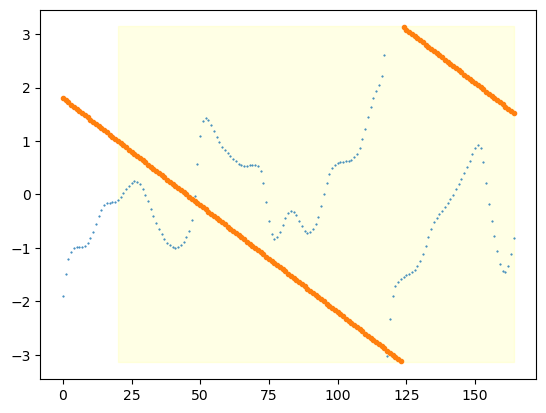

In [15]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = -0.04
intercept=1.8
line = slope*ix + intercept

plt.fill_betweenx([-np.pi, np.pi], tix_start, tix_end, color='yellow', alpha=0.1)

plt.plot(ix, wrap_angle(line), '.')

### Parameters to set

In [16]:
min_ix_range = 100
max_ix_range = 120

In [17]:
trajec = df_calibrated_interp

In [18]:
course = trajec.course_smoothish.values
abs_min_ix = tix_start
abs_max_ix = tix_end

In [19]:
trajec['search_phase'] = np.zeros_like(trajec.x.values)
trajec.loc[tix_start:tix_end, 'search_phase']  = 1

trajec['flow_direction'] = [flow_direction]*len(trajec.x.values)
trajec['flow_condition'] = [flow_condition]*len(trajec.x.values)
trajec['flow_speed'] = [flow_speed]*len(trajec.x.values)
trajec['body_length'] = [body_length]*len(trajec.x.values)

trajec['locomotion'] = [locomotion]*len(trajec.x.values)
trajec['medium'] = [medium]*len(trajec.x.values)
trajec['group'] = [group]*len(trajec.x.values)

In [20]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = np.min([min_ix_range, 50]), 
                                                  n_bootstraps=10, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0,
                                                  obj_id=trajec.obj_id_unique_event.values[0],
                                                  timestamps_sec=trajec.timestamps_sec,)

Restricted license - for non-production use only - expires 2027-11-29


SolverError: Solver 'GUROBI' failed. Try another solver, or solve with verbose=True for more information.

In [21]:
unifying_algo_fit['flow_direction'] = flow_direction
unifying_algo_fit['flow_condition'] = flow_condition
unifying_algo_fit['flow_speed'] = flow_speed
unifying_algo_fit['body_length'] = body_length

unifying_algo_fit['locomotion'] = locomotion
unifying_algo_fit['medium'] = medium
unifying_algo_fit['group'] = group



In [22]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [23]:
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,...,iteration,obj_id_unique_event,timestep_sec,flow_direction,flow_condition,flow_speed,body_length,locomotion,medium,group
7,38,153,0.134848,-6.588619,1.539337,0.865800,0.238010,0.238631,0.019737,0.019737,...,7,crab_12710,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
1,36,155,0.130594,6.515629,1.629947,0.854317,0.235960,0.238121,-0.036491,-0.036491,...,1,crab_12710,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
4,29,141,0.132031,-6.262486,1.653018,0.830692,0.167730,0.172202,-0.054264,-0.054264,...,4,crab_12710,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
6,48,157,0.130513,6.606995,1.625105,0.809657,0.260072,0.261691,-0.029789,-0.029789,...,6,crab_12710,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
5,54,158,0.135209,5.939749,1.509477,0.793335,0.270929,0.272891,0.031953,0.031953,...,5,crab_12710,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
8,25,134,0.136045,-6.378409,1.736698,0.838694,0.058691,0.079963,-0.127042,-0.127042,...,8,crab_12710,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
3,60,163,0.142538,4.869563,1.256924,0.752874,0.267022,0.313335,0.142676,0.142676,...,3,crab_12710,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
9,46,163,-0.013556,-5.462183,1.573201,0.847720,0.183263,0.183267,-0.001598,-0.001598,...,9,crab_12710,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
0,39,139,-0.020948,-4.288792,-2.527584,1.236596,0.300603,0.925896,0.440770,0.440770,...,0,crab_12710,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
2,24,127,0.012610,-0.746486,-3.122213,3.015303,0.317081,3.014290,0.052278,0.052278,...,2,crab_12710,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic


In [25]:
ix_all, course, linear_fit_angle, affine_fit_angle, shift_ix_adj = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

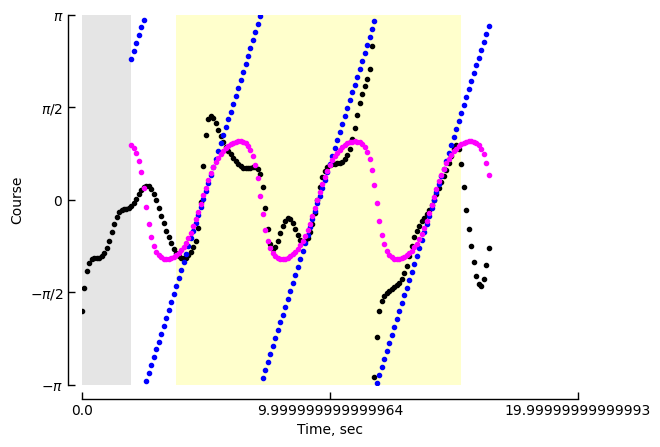

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [27]:
fname_trajec = fname.split('.')[0] + '_trajec.parquet'
trajec.to_parquet(fname_trajec)

unifying_algo_fit.to_parquet(fname.split('.')[0] + '_unifying_analysis.parquet')